# 21 — Assembly101 Staged KD Search and Text + KD Student

This notebook continues notebooks 19 and 20 without overwriting their
completed runs. It answers two questions:

1. Does a wider, validation-only search over the KD coefficient,
   temperature, and stage policy improve the video-only KD student?
2. Are logit distillation and the text-space auxiliary objective from
   notebook 20 complementary?

The search is deliberately staged rather than a full Cartesian grid:

1. extend `lambda_KD` at `T=4`, distilling all stages;
2. search temperature only for the selected coefficient;
3. compare all-stage versus final-stage KD only for the selected pair;
4. train one combined student using the selected KD configuration and
   notebook 20's validation-selected text configuration.

Hyperparameters are selected using validation data only. Test data is
evaluated only after every configuration has been fixed. Both final
students use `student(video)` at inference; neither the teacher nor the
text auxiliary path is called.


## Search protocol

| Stage | Candidates | Reused results | New full runs |
|---|---|---|---:|
| A: KD weight | existing `0.01, 0.05, 0.1` plus `0.2, 0.5, 1.0`; `T=4`, all stages | notebook 19 | 3 |
| B: temperature | `T = 1, 2, 4, 8` for the selected weight | selected `T=4` run | 3 |
| C: stage policy | all stages vs final stage | selected all-stage run | 1 |
| D: combined model | selected KD + notebook 20 selected text objective | notebook 20 initialization | 1 |

Selection score throughout:

\[
S_{val}=F1@25_{val}+0.01\,Edit_{val}.
\]

Maximum new full runs: eight. Completed runs are skipped and partial
runs resume from their last checkpoint.


## 1. Mount Google Drive


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 2. Imports, paths, and configuration


In [2]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import random
import time
import traceback

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 260)

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT
    / "text_assisted_tas"
    / "assembly101"
    / "coarse_mstcn_format"
    / "streaming_visual_features_v1"
)
DATA_ROOT = FEATURE_ROOT / "clip_vitb16"

NOTEBOOK18_SUMMARY = (
    FEATURE_ROOT
    / "runs"
    / "18_text_assisted_concat_teachers"
    / "final_summary_full.json"
)
NOTEBOOK19_ROOT = FEATURE_ROOT / "runs" / "19_video_only_kd_students"
NOTEBOOK19_SUMMARY = NOTEBOOK19_ROOT / "full" / "final_summary.json"
NOTEBOOK19_SHARED_INIT = (
    NOTEBOOK19_ROOT / "full" / "shared_student_initialization.pt"
)
NOTEBOOK20_ROOT = FEATURE_ROOT / "runs" / "20_learnable_text_students"
NOTEBOOK20_SUMMARY = NOTEBOOK20_ROOT / "full" / "final_summary.json"
NOTEBOOK20_SHARED_INIT = (
    NOTEBOOK20_ROOT / "full" / "shared_text_student_initialization.pt"
)

OUT_ROOT = FEATURE_ROOT / "runs" / "21_text_student_kd_search"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_MODE = "full"
# RUN_MODE = "smoke"

SEED = 7
RUN_CONFIGS = {
    "smoke": {
        "epochs": 3,
        "max_train_sequences": 64,
        "max_val_sequences": 32,
        "max_test_sequences": 32,
        "eval_every": 1,
        "patience_evals": None,
        "new_kd_lambdas": [0.2],
        "temperature_candidates": [2.0, 4.0],
    },
    "full": {
        "epochs": 120,
        "max_train_sequences": None,
        "max_val_sequences": None,
        "max_test_sequences": None,
        "eval_every": 5,
        "patience_evals": 12,
        "new_kd_lambdas": [0.2, 0.5, 1.0],
        "temperature_candidates": [1.0, 2.0, 4.0, 8.0],
    },
}

if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")
CFG = RUN_CONFIGS[RUN_MODE]

EXPECTED_VIDEO_DIM = 512
EXPECTED_TEXT_DIM = 512
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_NUM_CLASSES = 202

NUM_STAGES = 4
NUM_LAYERS = 6
NUM_F_MAPS = 64
DROPOUT = 0.5

BATCH_SIZE = 64
NUM_WORKERS = 0
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 5.0

SMOOTHING_WEIGHT = 0.15
SMOOTHING_CLIP_VALUE = 16.0

INITIAL_KD_TEMPERATURE = 4.0
NEW_KD_LAMBDAS = list(CFG["new_kd_lambdas"])
TEMPERATURE_CANDIDATES = list(CFG["temperature_candidates"])

INITIAL_TEXT_TEMPERATURE = 0.07
LEARNABLE_RESIDUAL_SCALE = 0.10

RESUME_IF_AVAILABLE = True
FORCE_RETRAIN_COMPLETED = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("RUN_MODE:", RUN_MODE)
print("CFG:", CFG)
print("NEW_KD_LAMBDAS:", NEW_KD_LAMBDAS)
print("TEMPERATURE_CANDIDATES:", TEMPERATURE_CANDIDATES)
print("DEVICE:", DEVICE)
print("OUT_ROOT:", OUT_ROOT)

if RUN_MODE == "full" and not torch.cuda.is_available():
    print("WARNING: full training is running without a GPU.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
RUN_MODE: full
CFG: {'epochs': 120, 'max_train_sequences': None, 'max_val_sequences': None, 'max_test_sequences': None, 'eval_every': 5, 'patience_evals': 12, 'new_kd_lambdas': [0.2, 0.5, 1.0], 'temperature_candidates': [1.0, 2.0, 4.0, 8.0]}
NEW_KD_LAMBDAS: [0.2, 0.5, 1.0]
TEMPERATURE_CANDIDATES: [1.0, 2.0, 4.0, 8.0]
DEVICE: cuda
OUT_ROOT: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search


## 3. Resolve completed notebook 18–20 artifacts


In [3]:
for name, path in {
    "CLIP feature dataset": DATA_ROOT,
    "notebook 18 summary": NOTEBOOK18_SUMMARY,
    "notebook 19 summary": NOTEBOOK19_SUMMARY,
    "notebook 19 shared initialization": NOTEBOOK19_SHARED_INIT,
    "notebook 20 summary": NOTEBOOK20_SUMMARY,
    "notebook 20 shared initialization": NOTEBOOK20_SHARED_INIT,
}.items():
    print(f"{name}: {path} -> {path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

notebook18 = json.loads(NOTEBOOK18_SUMMARY.read_text(encoding="utf-8"))
notebook19 = json.loads(NOTEBOOK19_SUMMARY.read_text(encoding="utf-8"))
notebook20 = json.loads(NOTEBOOK20_SUMMARY.read_text(encoding="utf-8"))

for number, summary in [(18, notebook18), (19, notebook19), (20, notebook20)]:
    if summary.get("status") != "completed":
        raise RuntimeError(f"Notebook {number} is not marked completed.")

teacher_key = "mstcn/clip_vitb16"
teacher_experiment = notebook18["experiments"][teacher_key]
TEACHER_CHECKPOINT = Path(
    notebook18["recommended_teacher_for_kd"]["teacher_checkpoint"]
)
TEXT_EMBEDDING_PATH = Path(
    teacher_experiment["input"]["text_embedding_path"]
)
TEXT_METADATA_PATH = Path(
    teacher_experiment["input"]["text_metadata_path"]
)
TRAIN_VIDEO_MEAN_PATH = Path(
    teacher_experiment["paths"]["train_video_mean"]
)
TRAIN_VIDEO_STD_PATH = Path(
    teacher_experiment["paths"]["train_video_std"]
)

selected_text = notebook20["selected_text_strategy"]
SELECTED_TEXT_MODE = str(selected_text["prototype_mode"])
SELECTED_TEXT_BETA = float(selected_text["text_beta"])
PROTOTYPE_ANCHOR_WEIGHT = float(
    notebook20["method"]["prototype_anchor_weight"]
)

for name, path in {
    "teacher checkpoint": TEACHER_CHECKPOINT,
    "CLIP action-text embeddings": TEXT_EMBEDDING_PATH,
    "CLIP action-text metadata": TEXT_METADATA_PATH,
    "train video mean": TRAIN_VIDEO_MEAN_PATH,
    "train video std": TRAIN_VIDEO_STD_PATH,
}.items():
    print(f"{name}: {path} -> {path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {name}: {path}")

print(
    json.dumps(
        {
            "notebook19_selected_kd_lambda": notebook19["selected_kd_lambda"],
            "notebook19_temperature": notebook19["losses"]["temperature"],
            "notebook20_text_mode": SELECTED_TEXT_MODE,
            "notebook20_text_beta": SELECTED_TEXT_BETA,
            "notebook20_validation": selected_text["validation_metrics"],
            "notebook20_test": selected_text["test"]["metrics"],
            "test_used_for_search": False,
        },
        indent=2,
    )
)


CLIP feature dataset: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16 -> True
notebook 18 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/18_text_assisted_concat_teachers/final_summary_full.json -> True
notebook 19 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/final_summary.json -> True
notebook 19 shared initialization: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/shared_student_initialization.pt -> True
notebook 20 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/final_summary.json

## 4. Reproducibility, mapping, and official split


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip()
    ]


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        class_id_text, label = line.split(maxsplit=1)
        class_id = int(class_id_text)
        if class_id in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[class_id] = label
        label_to_id[label] = class_id
    return id_to_label, label_to_id


def resolve_bundle(split_dir, split_name):
    split_dir = Path(split_dir)
    for candidate in [
        split_dir / f"{split_name}.bundle",
        split_dir / f"{split_name}.split1.bundle",
    ]:
        if candidate.exists():
            return candidate
    candidates = sorted(
        path
        for path in split_dir.glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
        and not path.name.lower().endswith(".partial.bundle")
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name}: {candidates}"
        )
    return candidates[0]


def read_bundle(path):
    sequence_ids = [Path(line).stem for line in read_nonempty_lines(path)]
    if len(sequence_ids) != len(set(sequence_ids)):
        raise ValueError(f"Duplicate IDs in {path}")
    return sequence_ids


def limit_ids(sequence_ids, maximum):
    if maximum is None:
        return list(sequence_ids)
    return list(sequence_ids)[: int(maximum)]


set_seed(SEED)
MAPPING_PATH = DATA_ROOT / "mapping.txt"
SPLIT_DIR = DATA_ROOT / "splits"
id_to_label, label_to_id = load_mapping(MAPPING_PATH)
num_classes = len(id_to_label)

if num_classes != EXPECTED_NUM_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_NUM_CLASSES} classes, found {num_classes}"
    )
if set(id_to_label) != set(range(num_classes)):
    raise ValueError("Class IDs must be contiguous from 0 to 201.")

train_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "train"))
val_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "val"))
test_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "test"))

assert set(train_ids_full).isdisjoint(set(val_ids_full))
assert set(train_ids_full).isdisjoint(set(test_ids_full))
assert set(val_ids_full).isdisjoint(set(test_ids_full))
assert len(set(train_ids_full) | set(val_ids_full) | set(test_ids_full)) == 680

train_ids = limit_ids(train_ids_full, CFG["max_train_sequences"])
val_ids = limit_ids(val_ids_full, CFG["max_val_sequences"])
test_ids = limit_ids(test_ids_full, CFG["max_test_sequences"])

print("Classes:", num_classes)
print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test reserved:", len(test_ids))


Classes: 202
Train: 393
Validation: 120
Test reserved: 167


## 5. Text bank, normalization, dataset, and loaders


In [5]:
text_embeddings = np.load(TEXT_EMBEDDING_PATH).astype(np.float32)
text_metadata = pd.read_csv(TEXT_METADATA_PATH)
required_columns = {"model_class_id", "action_cls", "prompt", "clip_model"}
missing_columns = required_columns - set(text_metadata.columns)
if missing_columns:
    raise KeyError(f"Missing text metadata columns: {sorted(missing_columns)}")

if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise ValueError(f"Unexpected text shape: {text_embeddings.shape}")

text_metadata = text_metadata.sort_values("model_class_id").reset_index(drop=True)
if not np.array_equal(
    text_metadata["model_class_id"].to_numpy(),
    np.arange(EXPECTED_NUM_CLASSES),
):
    raise ValueError("Text metadata does not cover IDs 0..201 exactly.")

for class_id in range(num_classes):
    action_name = str(text_metadata.loc[class_id, "action_cls"])
    if action_name != str(id_to_label[class_id]):
        raise ValueError(
            f"Text/mapping mismatch at {class_id}: "
            f"{action_name} != {id_to_label[class_id]}"
        )

text_embeddings /= np.maximum(
    np.linalg.norm(text_embeddings, axis=1, keepdims=True), 1e-12
)
text_embeddings = text_embeddings.astype(np.float32)
text_bank_tensor = torch.from_numpy(text_embeddings)

train_video_mean = np.load(TRAIN_VIDEO_MEAN_PATH).astype(np.float32)
train_video_std = np.load(TRAIN_VIDEO_STD_PATH).astype(np.float32)
if train_video_mean.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected mean shape: {train_video_mean.shape}")
if train_video_std.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected std shape: {train_video_std.shape}")
if np.any(train_video_std <= 0):
    raise ValueError("All train standard deviations must be positive.")


class Assembly101KDDataset(Dataset):
    def __init__(self, sequence_ids):
        self.sequence_ids = list(sequence_ids)
        self.feature_dir = DATA_ROOT / "features"
        self.gt_dir = DATA_ROOT / "groundTruth"

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]
        video = np.load(
            self.feature_dir / f"{sequence_id}.npy"
        ).astype(np.float32)
        label_names = read_nonempty_lines(
            self.gt_dir / f"{sequence_id}.txt"
        )
        labels = np.asarray(
            [label_to_id[label] for label in label_names], dtype=np.int64
        )

        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(
                f"Unexpected video shape for {sequence_id}: {video.shape}"
            )
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise ValueError(
                f"Unexpected labels for {sequence_id}: {labels.shape}"
            )
        if not np.isfinite(video).all():
            raise ValueError(f"Non-finite video values for {sequence_id}")

        video = (
            video - train_video_mean[:, None]
        ) / (
            train_video_std[:, None] + 1e-8
        )
        privileged_text = text_embeddings[labels].T.astype(np.float32)

        return {
            "sequence_id": sequence_id,
            "video": torch.from_numpy(video),
            "privileged_text": torch.from_numpy(privileged_text),
            "labels": torch.from_numpy(labels),
        }


train_dataset = Assembly101KDDataset(train_ids)
val_dataset = Assembly101KDDataset(val_ids)
test_dataset = Assembly101KDDataset(test_ids)


def make_train_loader(epoch):
    generator = torch.Generator()
    generator.manual_seed(SEED + int(epoch))
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

sample = next(iter(make_train_loader(1)))
assert sample["video"].shape[1:] == (
    EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH
)
assert sample["privileged_text"].shape[1:] == (
    EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH
)
assert sample["labels"].shape[1:] == (EXPECTED_TEMPORAL_LENGTH,)

print("Text bank:", tuple(text_bank_tensor.shape))
print("Train/val/test:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Video batch:", tuple(sample["video"].shape))
print("Privileged text batch:", tuple(sample["privileged_text"].shape))


Text bank: (202, 512)
Train/val/test: 393 120 167
Video batch: (64, 512, 16)
Privileged text batch: (64, 512, 16)


## 6. Temporal action segmentation metrics


In [6]:
IGNORE_CLASS_NAMES = {"background", "SIL", "silence"}
ignore_class_ids = {
    label_to_id[name]
    for name in IGNORE_CLASS_NAMES
    if name in label_to_id
}


def collapse_segments(frame_labels, ignored_ids=None):
    ignored_ids = set(ignored_ids or [])
    labels, starts, ends = [], [], []
    active = None
    for index, label in enumerate(frame_labels):
        label = int(label)
        if label in ignored_ids:
            if active is not None:
                ends.append(index)
                active = None
            continue
        if label != active:
            if active is not None:
                ends.append(index)
            labels.append(label)
            starts.append(index)
            active = label
    if active is not None:
        ends.append(len(frame_labels))
    return labels, starts, ends


def levenshtein_distance(predicted, target):
    distance = np.zeros(
        (len(predicted) + 1, len(target) + 1), dtype=np.int32
    )
    distance[:, 0] = np.arange(len(predicted) + 1)
    distance[0, :] = np.arange(len(target) + 1)
    for row in range(1, len(predicted) + 1):
        for column in range(1, len(target) + 1):
            substitution = int(predicted[row - 1] != target[column - 1])
            distance[row, column] = min(
                distance[row - 1, column] + 1,
                distance[row, column - 1] + 1,
                distance[row - 1, column - 1] + substitution,
            )
    return int(distance[-1, -1])


def edit_score_single(prediction, target, ignored_ids=None):
    predicted_segments, _, _ = collapse_segments(prediction, ignored_ids)
    target_segments, _, _ = collapse_segments(target, ignored_ids)
    if not predicted_segments and not target_segments:
        return 100.0
    denominator = max(len(predicted_segments), len(target_segments))
    if denominator == 0:
        return 0.0
    distance = levenshtein_distance(predicted_segments, target_segments)
    return (1.0 - distance / denominator) * 100.0


def f_score_single(prediction, target, overlap, ignored_ids=None):
    predicted_labels, predicted_starts, predicted_ends = collapse_segments(
        prediction, ignored_ids
    )
    target_labels, target_starts, target_ends = collapse_segments(
        target, ignored_ids
    )
    true_positives = 0
    false_positives = 0
    hits = np.zeros(len(target_labels), dtype=np.float32)

    for predicted_index in range(len(predicted_labels)):
        best_iou = 0.0
        best_target = -1
        for target_index in range(len(target_labels)):
            if predicted_labels[predicted_index] != target_labels[target_index]:
                continue
            intersection = (
                min(predicted_ends[predicted_index], target_ends[target_index])
                - max(predicted_starts[predicted_index], target_starts[target_index])
            )
            union = (
                max(predicted_ends[predicted_index], target_ends[target_index])
                - min(predicted_starts[predicted_index], target_starts[target_index])
            )
            iou = max(intersection, 0) / union if union > 0 else 0.0
            if iou > best_iou:
                best_iou = iou
                best_target = target_index
        if best_iou >= overlap and best_target >= 0 and hits[best_target] == 0:
            true_positives += 1
            hits[best_target] = 1
        else:
            false_positives += 1

    false_negatives = len(target_labels) - int(hits.sum())
    return true_positives, false_positives, false_negatives


def compute_metrics(predictions, targets, ignored_ids=None):
    total_correct = 0
    total_positions = 0
    edit_scores = []
    f_statistics = {
        0.10: [0, 0, 0],
        0.25: [0, 0, 0],
        0.50: [0, 0, 0],
    }
    for sequence_id, prediction in predictions.items():
        target = targets[sequence_id]
        total_correct += int((prediction == target).sum())
        total_positions += len(target)
        edit_scores.append(edit_score_single(prediction, target, ignored_ids))
        for overlap in f_statistics:
            tp, fp, fn = f_score_single(
                prediction, target, overlap, ignored_ids
            )
            f_statistics[overlap][0] += tp
            f_statistics[overlap][1] += fp
            f_statistics[overlap][2] += fn

    metrics = {
        "acc": 100.0 * total_correct / max(total_positions, 1),
        "edit": float(np.mean(edit_scores)) if edit_scores else 0.0,
    }
    for overlap, (tp, fp, fn) in f_statistics.items():
        precision = tp / max(tp + fp, 1e-8)
        recall = tp / max(tp + fn, 1e-8)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
        metrics[f"f1@{int(overlap * 100)}"] = 100.0 * f1
    return metrics


def round_metrics(metrics):
    return {key: round(float(value), 2) for key, value in metrics.items()}


def selection_score(metrics):
    return float(metrics["f1@25"]) + 0.01 * float(metrics["edit"])


print("Ignored class IDs:", ignore_class_ids)
print("Metrics ready.")


Ignored class IDs: set()
Metrics ready.


## 7. Exact teacher, video-only student, and text-aligned student


In [7]:
class DilatedResidualLayer(nn.Module):
    def __init__(self, dilation, channels, dropout):
        super().__init__()
        self.conv_dilated = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation,
        )
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        output = F.relu(self.conv_dilated(inputs))
        output = self.conv_1x1(output)
        output = self.dropout(output)
        return inputs + output


class SingleStage(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_projection = nn.Conv1d(
            input_dim, NUM_F_MAPS, kernel_size=1
        )
        self.layers = nn.ModuleList(
            [
                DilatedResidualLayer(
                    dilation=2 ** layer_index,
                    channels=NUM_F_MAPS,
                    dropout=DROPOUT,
                )
                for layer_index in range(NUM_LAYERS)
            ]
        )
        self.output_projection = nn.Conv1d(
            NUM_F_MAPS, num_classes, kernel_size=1
        )

    def forward(self, inputs, return_hidden=False):
        hidden = self.input_projection(inputs)
        for layer in self.layers:
            hidden = layer(hidden)
        logits = self.output_projection(hidden)
        if return_hidden:
            return logits, hidden
        return logits


class MSTCNTeacher(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stage1 = SingleStage(
            EXPECTED_VIDEO_DIM + EXPECTED_TEXT_DIM, num_classes
        )
        self.refinement_stages = nn.ModuleList(
            [
                SingleStage(num_classes, num_classes)
                for _ in range(NUM_STAGES - 1)
            ]
        )

    def forward(self, video, privileged_text):
        logits = self.stage1(torch.cat([video, privileged_text], dim=1))
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        return torch.stack(outputs, dim=0)


class MSTCNVideoStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stage1 = SingleStage(EXPECTED_VIDEO_DIM, num_classes)
        self.refinement_stages = nn.ModuleList(
            [
                SingleStage(num_classes, num_classes)
                for _ in range(NUM_STAGES - 1)
            ]
        )

    def forward(self, video):
        logits = self.stage1(video)
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        return torch.stack(outputs, dim=0)


class MSTCNTextEmbeddingStudent(nn.Module):
    def __init__(self, num_classes, clip_text_bank, prototype_mode):
        super().__init__()
        if prototype_mode not in {"fixed", "learnable"}:
            raise ValueError(f"Unknown prototype mode: {prototype_mode}")
        self.prototype_mode = prototype_mode
        self.stage1 = SingleStage(EXPECTED_VIDEO_DIM, num_classes)
        self.refinement_stages = nn.ModuleList(
            [
                SingleStage(num_classes, num_classes)
                for _ in range(NUM_STAGES - 1)
            ]
        )
        self.video_to_text = nn.Conv1d(
            NUM_F_MAPS, EXPECTED_TEXT_DIM, kernel_size=1
        )
        self.register_buffer(
            "clip_text_bank",
            F.normalize(clip_text_bank.float().clone(), dim=-1),
        )
        self.prototype_delta = nn.Parameter(
            torch.zeros_like(self.clip_text_bank),
            requires_grad=(prototype_mode == "learnable"),
        )
        self.logit_scale = nn.Parameter(
            torch.tensor(math.log(1.0 / INITIAL_TEXT_TEMPERATURE))
        )

    def adapted_prototypes(self):
        prototypes = (
            self.clip_text_bank
            + LEARNABLE_RESIDUAL_SCALE * self.prototype_delta
        )
        return F.normalize(prototypes, dim=-1)

    def forward(self, video, return_text_aux=False):
        logits, hidden = self.stage1(video, return_hidden=True)
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        stacked_outputs = torch.stack(outputs, dim=0)
        if not return_text_aux:
            return stacked_outputs
        auxiliary = {
            "projected_video": F.normalize(
                self.video_to_text(hidden), dim=1
            ),
            "prototypes": self.adapted_prototypes(),
            "logit_scale": self.logit_scale.exp().clamp(max=100.0),
        }
        return stacked_outputs, auxiliary


def create_teacher():
    return MSTCNTeacher(num_classes).to(DEVICE)


def create_video_student():
    return MSTCNVideoStudent(num_classes).to(DEVICE)


def create_text_student(prototype_mode):
    return MSTCNTextEmbeddingStudent(
        num_classes=num_classes,
        clip_text_bank=text_bank_tensor,
        prototype_mode=prototype_mode,
    ).to(DEVICE)


with torch.no_grad():
    dummy_video = torch.zeros(
        2, EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH, device=DEVICE
    )
    dummy_text = torch.zeros(
        2, EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH, device=DEVICE
    )
    teacher_shape = create_teacher()(dummy_video, dummy_text).shape
    video_shape = create_video_student()(dummy_video).shape
    text_model = create_text_student(SELECTED_TEXT_MODE)
    text_shape, auxiliary = text_model(
        dummy_video, return_text_aux=True
    )

expected_shape = (
    NUM_STAGES, 2, num_classes, EXPECTED_TEMPORAL_LENGTH
)
assert teacher_shape == expected_shape
assert video_shape == expected_shape
assert text_shape.shape == expected_shape
assert auxiliary["prototypes"].shape == (
    num_classes, EXPECTED_TEXT_DIM
)

print("Teacher output:", tuple(teacher_shape))
print("Video student output:", tuple(video_shape))
print("Text student output:", tuple(text_shape.shape))
print("Final inference signatures: student(video)")

del dummy_video, dummy_text, text_model, text_shape, auxiliary
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Teacher output: (4, 2, 202, 16)
Video student output: (4, 2, 202, 16)
Text student output: (4, 2, 202, 16)
Final inference signatures: student(video)


## 8. Load and freeze the privileged teacher


In [8]:
def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


teacher_checkpoint = load_checkpoint(TEACHER_CHECKPOINT)
teacher = create_teacher()
teacher.load_state_dict(
    teacher_checkpoint["model_state_dict"], strict=True
)
teacher.eval()
for parameter in teacher.parameters():
    parameter.requires_grad_(False)

with torch.no_grad():
    teacher_test_output = teacher(
        sample["video"][:2].to(DEVICE),
        sample["privileged_text"][:2].to(DEVICE),
    )
assert teacher_test_output.shape == (
    NUM_STAGES, 2, num_classes, EXPECTED_TEMPORAL_LENGTH
)

print("Teacher checkpoint epoch:", teacher_checkpoint.get("epoch"))
print("Teacher output:", tuple(teacher_test_output.shape))
print(
    "Teacher trainable parameters:",
    sum(parameter.numel() for parameter in teacher.parameters() if parameter.requires_grad),
)
del teacher_test_output


Teacher checkpoint epoch: 120
Teacher output: (4, 2, 202, 16)
Teacher trainable parameters: 0


## 9. Segmentation, KD, and text-alignment losses


In [9]:
def supervised_loss(outputs, targets):
    total = torch.zeros((), device=outputs.device)
    ce_sum = 0.0
    smooth_sum = 0.0
    for stage_index in range(outputs.shape[0]):
        logits = outputs[stage_index]
        ce = F.cross_entropy(
            logits.permute(0, 2, 1).reshape(-1, logits.shape[1]),
            targets.reshape(-1),
        )
        log_probabilities = F.log_softmax(logits, dim=1)
        smooth = F.mse_loss(
            log_probabilities[:, :, 1:],
            log_probabilities.detach()[:, :, :-1],
            reduction="none",
        )
        smooth = torch.clamp(
            smooth, min=0.0, max=SMOOTHING_CLIP_VALUE
        ).mean()
        total = total + ce + SMOOTHING_WEIGHT * smooth
        ce_sum += float(ce.detach().cpu())
        smooth_sum += float(smooth.detach().cpu())
    return total, {
        "segmentation": float(total.detach().cpu()),
        "cross_entropy_sum": ce_sum,
        "smoothing_sum": smooth_sum,
    }


def distillation_loss(
    student_outputs,
    teacher_outputs,
    temperature,
    stage_policy,
):
    if student_outputs.shape != teacher_outputs.shape:
        raise ValueError(
            f"Student/teacher mismatch: {student_outputs.shape} "
            f"vs {teacher_outputs.shape}"
        )
    if stage_policy == "all":
        stage_indices = range(student_outputs.shape[0])
    elif stage_policy == "final":
        stage_indices = [student_outputs.shape[0] - 1]
    else:
        raise ValueError(f"Unknown stage policy: {stage_policy}")

    losses = []
    for stage_index in stage_indices:
        student_logits = (
            student_outputs[stage_index]
            .permute(0, 2, 1)
            .reshape(-1, student_outputs.shape[2])
        )
        teacher_logits = (
            teacher_outputs[stage_index]
            .detach()
            .permute(0, 2, 1)
            .reshape(-1, teacher_outputs.shape[2])
        )
        student_log_probability = F.log_softmax(
            student_logits / float(temperature), dim=-1
        )
        teacher_probability = F.softmax(
            teacher_logits / float(temperature), dim=-1
        )
        losses.append(
            F.kl_div(
                student_log_probability,
                teacher_probability,
                reduction="batchmean",
            )
            * (float(temperature) ** 2)
        )
    return torch.stack(losses).mean()


def text_alignment_loss(auxiliary, targets):
    similarity_logits = auxiliary["logit_scale"] * torch.einsum(
        "bdt,cd->bct",
        auxiliary["projected_video"],
        auxiliary["prototypes"],
    )
    return F.cross_entropy(
        similarity_logits.permute(0, 2, 1).reshape(-1, num_classes),
        targets.reshape(-1),
    )


def prototype_anchor_loss(model):
    if model.prototype_mode != "learnable":
        return torch.zeros((), device=DEVICE)
    adapted = model.adapted_prototypes()
    return (
        1.0 - (adapted * model.clip_text_bank).sum(dim=-1)
    ).mean()


def kd_total_loss(
    outputs,
    targets,
    teacher_outputs,
    kd_lambda,
    temperature,
    stage_policy,
):
    segmentation, parts = supervised_loss(outputs, targets)
    kd = distillation_loss(
        outputs, teacher_outputs, temperature, stage_policy
    )
    total = segmentation + float(kd_lambda) * kd
    return total, {
        **parts,
        "kd_unweighted": float(kd.detach().cpu()),
        "kd_weighted": float((float(kd_lambda) * kd).detach().cpu()),
        "total": float(total.detach().cpu()),
    }


def combined_total_loss(
    model,
    outputs,
    auxiliary,
    targets,
    teacher_outputs,
    kd_lambda,
    temperature,
    stage_policy,
    text_beta,
):
    segmentation, parts = supervised_loss(outputs, targets)
    kd = distillation_loss(
        outputs, teacher_outputs, temperature, stage_policy
    )
    text = text_alignment_loss(auxiliary, targets)
    anchor = prototype_anchor_loss(model)
    total = (
        segmentation
        + float(kd_lambda) * kd
        + float(text_beta) * text
        + PROTOTYPE_ANCHOR_WEIGHT * anchor
    )
    return total, {
        **parts,
        "kd_unweighted": float(kd.detach().cpu()),
        "kd_weighted": float((float(kd_lambda) * kd).detach().cpu()),
        "text_unweighted": float(text.detach().cpu()),
        "text_weighted": float((float(text_beta) * text).detach().cpu()),
        "prototype_anchor": float(anchor.detach().cpu()),
        "total": float(total.detach().cpu()),
    }


print("KD: L_seg + lambda_KD * L_KD")
print(
    "Combined: L_seg + lambda_KD * L_KD + "
    "beta_text * L_text + gamma_anchor * L_anchor"
)


KD: L_seg + lambda_KD * L_KD
Combined: L_seg + lambda_KD * L_KD + beta_text * L_text + gamma_anchor * L_anchor


## 10. Common initializations and video-only evaluation


In [10]:
def fingerprint(state_dict):
    digest = hashlib.sha256()
    for key in sorted(state_dict):
        tensor = state_dict[key].detach().cpu().contiguous()
        digest.update(key.encode("utf-8"))
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()


notebook19_shared_payload = load_checkpoint(NOTEBOOK19_SHARED_INIT)
video_shared_state = notebook19_shared_payload["model_state_dict"]
video_shared_fingerprint = fingerprint(video_shared_state)

notebook20_shared_payload = load_checkpoint(NOTEBOOK20_SHARED_INIT)
text_shared_state = notebook20_shared_payload["model_state_dict"]
text_shared_fingerprint = fingerprint(text_shared_state)

video_initialization_test = create_video_student()
video_initialization_test.load_state_dict(video_shared_state, strict=True)
assert fingerprint(video_initialization_test.state_dict()) == video_shared_fingerprint

text_initialization_test = create_text_student(SELECTED_TEXT_MODE)
text_initialization_test.load_state_dict(text_shared_state, strict=True)
assert fingerprint(text_initialization_test.state_dict()) == text_shared_fingerprint

del video_initialization_test, text_initialization_test
gc.collect()


@torch.no_grad()
def evaluate_student(
    model,
    loader,
    save_predictions=False,
    prediction_dir=None,
):
    model.eval()
    predictions = {}
    targets = {}
    if save_predictions:
        prediction_dir = Path(prediction_dir)
        prediction_dir.mkdir(parents=True, exist_ok=True)

    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].cpu().numpy()
        sequence_ids = list(batch["sequence_id"])

        # Strictly video-only: teacher and text auxiliary path are not called.
        outputs = model(video)
        predicted = outputs[-1].argmax(dim=1).detach().cpu().numpy()

        for index, sequence_id in enumerate(sequence_ids):
            pred_ids = predicted[index].astype(np.int64)
            target_ids = labels[index].astype(np.int64)
            predictions[sequence_id] = pred_ids
            targets[sequence_id] = target_ids
            if save_predictions:
                pred_labels = [id_to_label[int(value)] for value in pred_ids]
                (prediction_dir / f"{sequence_id}.txt").write_text(
                    "\n".join(pred_labels) + "\n", encoding="utf-8"
                )

    return (
        compute_metrics(predictions, targets, ignore_class_ids),
        predictions,
        targets,
    )


print("Video initialization fingerprint:", video_shared_fingerprint)
print("Text initialization fingerprint:", text_shared_fingerprint)
print("Validation/test inference: student(video)")


Video initialization fingerprint: 9b6c82355bad7c451aa6ee11584877b3dee106a62bef930a1290ce8674159566
Text initialization fingerprint: a3db0b501cddbb5670c0cd3655b7004642323d8d74b981e5d72ac23ce448d1dc
Validation/test inference: student(video)


## 11. Candidate utilities and one resumable KD-only run


In [11]:
def value_name(value):
    return (
        f"{float(value):.5f}"
        .rstrip("0")
        .rstrip(".")
        .replace(".", "p")
    )


def kd_experiment_name(kd_lambda, temperature, stage_policy):
    return (
        f"kd_lambda_{value_name(kd_lambda)}_"
        f"temperature_{value_name(temperature)}_"
        f"policy_{stage_policy}"
    )


def candidate_from_summary(summary, source="notebook21"):
    return {
        "source": source,
        "experiment": summary["experiment"],
        "kd_lambda": float(summary["kd_lambda"]),
        "temperature": float(summary["temperature"]),
        "stage_policy": summary["stage_policy"],
        "best_epoch": int(summary["training"]["best_epoch"]),
        "best_validation_metrics": dict(
            summary["best_validation_metrics"]
        ),
        "best_validation_score": float(
            summary["best_validation_score"]
        ),
        "checkpoint": summary["paths"]["best_student"],
    }


def candidate_row(candidate):
    metrics = candidate["best_validation_metrics"]
    return {
        "source": candidate["source"],
        "experiment": candidate["experiment"],
        "kd_lambda": candidate["kd_lambda"],
        "temperature": candidate["temperature"],
        "stage_policy": candidate["stage_policy"],
        "best_epoch": candidate["best_epoch"],
        "val_acc": metrics["acc"],
        "val_edit": metrics["edit"],
        "val_f1@10": metrics["f1@10"],
        "val_f1@25": metrics["f1@25"],
        "val_f1@50": metrics["f1@50"],
        "selection_score": candidate["best_validation_score"],
        "checkpoint": candidate["checkpoint"],
    }


def select_candidate(candidates):
    if not candidates:
        raise RuntimeError("No candidates to select from.")
    return max(
        candidates,
        key=lambda item: (
            float(item["best_validation_score"]),
            float(item["best_validation_metrics"]["f1@25"]),
            float(item["best_validation_metrics"]["edit"]),
        ),
    )


def train_kd_experiment(kd_lambda, temperature, stage_policy):
    kd_lambda = float(kd_lambda)
    temperature = float(temperature)
    name = kd_experiment_name(kd_lambda, temperature, stage_policy)
    experiment_root = OUT_ROOT / RUN_MODE / "kd_only" / name
    model_dir = experiment_root / "models"
    result_dir = experiment_root / "results"
    model_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    best_path = model_dir / "best_student.pt"
    last_path = model_dir / "last_checkpoint.pt"
    history_path = result_dir / "training_history.csv"
    summary_path = result_dir / "validation_summary.json"

    if summary_path.exists() and not FORCE_RETRAIN_COMPLETED:
        previous = json.loads(summary_path.read_text(encoding="utf-8"))
        if previous.get("status") == "validation_complete":
            print("Skipping completed:", name)
            return previous

    set_seed(SEED)
    student = create_video_student()
    student.load_state_dict(video_shared_state, strict=True)
    if fingerprint(student.state_dict()) != video_shared_fingerprint:
        raise RuntimeError("Video shared initialization did not load exactly.")

    optimizer = torch.optim.AdamW(
        student.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"]
    )

    start_epoch = 1
    best_score = -math.inf
    best_validation_metrics = None
    no_improvement_evals = 0
    history = []

    if RESUME_IF_AVAILABLE and last_path.exists():
        checkpoint = load_checkpoint(last_path)
        compatible = (
            checkpoint.get("run_mode") == RUN_MODE
            and float(checkpoint.get("kd_lambda")) == kd_lambda
            and float(checkpoint.get("temperature")) == temperature
            and checkpoint.get("stage_policy") == stage_policy
            and checkpoint.get("initialization_fingerprint")
            == video_shared_fingerprint
        )
        if compatible:
            student.load_state_dict(checkpoint["model_state_dict"], strict=True)
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            start_epoch = int(checkpoint["epoch"]) + 1
            best_score = float(checkpoint.get("best_score", -math.inf))
            best_validation_metrics = checkpoint.get(
                "best_validation_metrics"
            )
            no_improvement_evals = int(
                checkpoint.get("no_improvement_evals", 0)
            )
            history = list(checkpoint.get("history", []))
            print("Resuming", name, "from epoch", start_epoch)

    print("\n" + "=" * 96)
    print("KD EXPERIMENT:", name)
    print("lambda_KD:", kd_lambda)
    print("temperature:", temperature)
    print("stage policy:", stage_policy)
    print("validation/test input: video only")
    print("=" * 96)

    start_time = time.time()
    stopped_early = False

    for epoch in range(start_epoch, CFG["epochs"] + 1):
        student.train()
        total_values = []
        segmentation_values = []
        kd_values = []

        for batch in make_train_loader(epoch):
            video = batch["video"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)
            privileged_text = batch["privileged_text"].to(
                DEVICE, non_blocking=True
            )

            with torch.no_grad():
                teacher_outputs = teacher(video, privileged_text)

            optimizer.zero_grad(set_to_none=True)
            outputs = student(video)
            loss, parts = kd_total_loss(
                outputs,
                labels,
                teacher_outputs,
                kd_lambda,
                temperature,
                stage_policy,
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP)
            optimizer.step()

            total_values.append(parts["total"])
            segmentation_values.append(parts["segmentation"])
            kd_values.append(parts["kd_unweighted"])

        scheduler.step()
        row = {
            "experiment": name,
            "kd_lambda": kd_lambda,
            "temperature": temperature,
            "stage_policy": stage_policy,
            "epoch": epoch,
            "train_total_loss": float(np.mean(total_values)),
            "train_segmentation_loss": float(np.mean(segmentation_values)),
            "train_kd_loss": float(np.mean(kd_values)),
            "learning_rate": float(scheduler.get_last_lr()[0]),
        }

        evaluate_now = (
            epoch == 1
            or epoch % CFG["eval_every"] == 0
            or epoch == CFG["epochs"]
        )
        if evaluate_now:
            validation_metrics, _, _ = evaluate_student(student, val_loader)
            row.update(
                {
                    f"val_{key}": value
                    for key, value in validation_metrics.items()
                }
            )
            score = selection_score(validation_metrics)
            improved = score > best_score
            if improved:
                best_score = score
                best_validation_metrics = dict(validation_metrics)
                no_improvement_evals = 0
                torch.save(
                    {
                        "epoch": epoch,
                        "run_mode": RUN_MODE,
                        "experiment": name,
                        "kd_lambda": kd_lambda,
                        "temperature": temperature,
                        "stage_policy": stage_policy,
                        "student_input": "video only",
                        "teacher_checkpoint": str(TEACHER_CHECKPOINT),
                        "initialization_fingerprint": video_shared_fingerprint,
                        "model_state_dict": student.state_dict(),
                        "validation_metrics": validation_metrics,
                        "selection_score": score,
                    },
                    best_path,
                )
            else:
                no_improvement_evals += 1

            print(
                f"{name} epoch {epoch:03d} "
                f"total={row['train_total_loss']:.4f} "
                f"seg={row['train_segmentation_loss']:.4f} "
                f"kd={row['train_kd_loss']:.4f} "
                f"val_acc={validation_metrics['acc']:.2f} "
                f"val_edit={validation_metrics['edit']:.2f} "
                f"val_f1@25={validation_metrics['f1@25']:.2f} "
                f"best={'yes' if improved else 'no'}"
            )
        else:
            print(
                f"{name} epoch {epoch:03d} "
                f"total={row['train_total_loss']:.4f} "
                f"seg={row['train_segmentation_loss']:.4f} "
                f"kd={row['train_kd_loss']:.4f}"
            )

        history.append(row)
        torch.save(
            {
                "epoch": epoch,
                "run_mode": RUN_MODE,
                "experiment": name,
                "kd_lambda": kd_lambda,
                "temperature": temperature,
                "stage_policy": stage_policy,
                "initialization_fingerprint": video_shared_fingerprint,
                "model_state_dict": student.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_score": best_score,
                "best_validation_metrics": best_validation_metrics,
                "no_improvement_evals": no_improvement_evals,
                "history": history,
            },
            last_path,
        )
        pd.DataFrame(history).to_csv(history_path, index=False)

        patience = CFG["patience_evals"]
        if (
            evaluate_now
            and patience is not None
            and no_improvement_evals >= patience
        ):
            stopped_early = True
            print("Early stopping after", no_improvement_evals, "evaluations.")
            break

    if not best_path.exists():
        raise RuntimeError(f"No best checkpoint saved for {name}")

    best_checkpoint = load_checkpoint(best_path)
    summary = {
        "status": "validation_complete",
        "run_mode": RUN_MODE,
        "experiment": name,
        "kd_lambda": kd_lambda,
        "temperature": temperature,
        "stage_policy": stage_policy,
        "teacher_used_during_training": True,
        "student_training_input": "video + labels + teacher soft targets",
        "student_validation_input": "video only",
        "student_test_input": "video only",
        "student_deployable": True,
        "initialization_fingerprint": video_shared_fingerprint,
        "training": {
            "maximum_epochs": CFG["epochs"],
            "best_epoch": int(best_checkpoint["epoch"]),
            "stopped_early": stopped_early,
            "minutes_this_run": (time.time() - start_time) / 60.0,
            "batch_size": BATCH_SIZE,
            "seed": SEED,
        },
        "best_validation_score": float(best_checkpoint["selection_score"]),
        "best_validation_metrics": round_metrics(
            best_checkpoint["validation_metrics"]
        ),
        "test_metrics": None,
        "paths": {
            "best_student": str(best_path),
            "last_checkpoint": str(last_path),
            "training_history": str(history_path),
        },
    }
    summary_path.write_text(
        json.dumps(summary, indent=2), encoding="utf-8"
    )
    print(
        json.dumps(
            {
                "experiment": name,
                "best_epoch": summary["training"]["best_epoch"],
                "best_validation_metrics": summary["best_validation_metrics"],
                "best_student": summary["paths"]["best_student"],
            },
            indent=2,
        )
    )

    del student, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


## 12. Stage A — extend the KD coefficient search


In [12]:
notebook19_candidates = []
notebook19_temperature = float(notebook19["losses"]["temperature"])
notebook19_policy = (
    "all" if notebook19["losses"]["distill_all_stages"] else "final"
)

# Full notebook 19 results are comparable only to a full notebook 21 run.
# Smoke mode intentionally trains its own small candidates instead.
source_rows = notebook19["kd_ablation"] if RUN_MODE == "full" else []

for row in source_rows:
    kd_lambda = float(row["kd_lambda"])
    if kd_lambda <= 0:
        continue
    metrics = {
        "acc": float(row["val_acc"]),
        "edit": float(row["val_edit"]),
        "f1@10": float(row["val_f1@10"]),
        "f1@25": float(row["val_f1@25"]),
        "f1@50": float(row["val_f1@50"]),
    }
    notebook19_candidates.append(
        {
            "source": "notebook19",
            "experiment": str(row["experiment"]),
            "kd_lambda": kd_lambda,
            "temperature": notebook19_temperature,
            "stage_policy": notebook19_policy,
            "best_epoch": int(row["best_epoch"]),
            "best_validation_metrics": metrics,
            "best_validation_score": float(
                row.get("validation_selection_score", selection_score(metrics))
            ),
            "checkpoint": str(row["best_student"]),
        }
    )

try:
    stage_a_new_candidates = []
    for kd_lambda in NEW_KD_LAMBDAS:
        summary = train_kd_experiment(
            kd_lambda=kd_lambda,
            temperature=INITIAL_KD_TEMPERATURE,
            stage_policy="all",
        )
        stage_a_new_candidates.append(candidate_from_summary(summary))
except Exception:
    error_dir = OUT_ROOT / RUN_MODE / "errors"
    error_dir.mkdir(parents=True, exist_ok=True)
    error_path = error_dir / "stage_a_traceback.txt"
    error_path.write_text(traceback.format_exc(), encoding="utf-8")
    print("Saved traceback:", error_path)
    raise

stage_a_candidates = notebook19_candidates + stage_a_new_candidates
stage_a_selected = select_candidate(stage_a_candidates)
stage_a_df = (
    pd.DataFrame([candidate_row(item) for item in stage_a_candidates])
    .sort_values(
        ["selection_score", "val_f1@25", "val_edit"],
        ascending=False,
    )
    .reset_index(drop=True)
)
stage_a_csv = OUT_ROOT / RUN_MODE / "stage_a_kd_lambda_search.csv"
stage_a_md = OUT_ROOT / RUN_MODE / "stage_a_kd_lambda_search.md"
stage_a_df.to_csv(stage_a_csv, index=False)
stage_a_md.write_text(stage_a_df.to_markdown(index=False), encoding="utf-8")

display(stage_a_df)
print("Stage A selected lambda:", stage_a_selected["kd_lambda"])
print("Selection used test data:", False)
print("Saved:", stage_a_csv)


Skipping completed: kd_lambda_0p2_temperature_4_policy_all
Skipping completed: kd_lambda_0p5_temperature_4_policy_all
Skipping completed: kd_lambda_1_temperature_4_policy_all


,source,experiment,kd_lambda,temperature,stage_policy,best_epoch,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50,selection_score,checkpoint
0,notebook21,kd_lambda_0p2_temperature_4_policy_all,0.20,4.0,all,90,30.42,26.36,29.60,25.94,19.27,26.208221,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_4_policy_all/models/best_student.pt
1,notebook21,kd_lambda_0p5_temperature_4_policy_all,0.50,4.0,all,100,30.36,25.80,29.61,25.67,19.44,25.925138,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p5_temperature_4_policy_all/models/best_student.pt
2,notebook21,kd_lambda_1_temperature_4_policy_all,1.00,4.0,all,65,29.84,25.98,28.99,25.17,19.58,25.434616,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_1_temperature_4_policy_all/models/best_student.pt
3,notebook19,kd_lambda_0p1,0.10,4.0,all,100,29.90,26.25,28.86,25.02,18.47,25.278568,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/kd_lambda_0p1/models/best_student.pt
4,notebook19,kd_lambda_0p05,0.05,4.0,all,80,30.00,25.99,28.81,24.97,18.18,25.227876,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/kd_lambda_0p05/models/best_student.pt
5,notebook19,kd_lambda_0p01,0.01,4.0,all,80,29.95,25.89,28.99,24.65,18.39,24.907668,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/kd_lambda_0p01/models/best_student.pt


Stage A selected lambda: 0.2
Selection used test data: False
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/stage_a_kd_lambda_search.csv


## 13. Stage B — temperature search for the selected coefficient


In [13]:
selected_lambda = float(stage_a_selected["kd_lambda"])
stage_b_candidates = [stage_a_selected]

try:
    for temperature in TEMPERATURE_CANDIDATES:
        temperature = float(temperature)
        already_present = any(
            math.isclose(float(item["temperature"]), temperature)
            and item["stage_policy"] == "all"
            for item in stage_b_candidates
        )
        if already_present:
            print("Reusing temperature candidate:", temperature)
            continue
        summary = train_kd_experiment(
            kd_lambda=selected_lambda,
            temperature=temperature,
            stage_policy="all",
        )
        stage_b_candidates.append(candidate_from_summary(summary))
except Exception:
    error_dir = OUT_ROOT / RUN_MODE / "errors"
    error_dir.mkdir(parents=True, exist_ok=True)
    error_path = error_dir / "stage_b_traceback.txt"
    error_path.write_text(traceback.format_exc(), encoding="utf-8")
    print("Saved traceback:", error_path)
    raise

stage_b_selected = select_candidate(stage_b_candidates)
stage_b_df = (
    pd.DataFrame([candidate_row(item) for item in stage_b_candidates])
    .sort_values(
        ["selection_score", "val_f1@25", "val_edit"],
        ascending=False,
    )
    .reset_index(drop=True)
)
stage_b_csv = OUT_ROOT / RUN_MODE / "stage_b_temperature_search.csv"
stage_b_md = OUT_ROOT / RUN_MODE / "stage_b_temperature_search.md"
stage_b_df.to_csv(stage_b_csv, index=False)
stage_b_md.write_text(stage_b_df.to_markdown(index=False), encoding="utf-8")

display(stage_b_df)
print("Stage B selected temperature:", stage_b_selected["temperature"])
print("Selection used test data:", False)
print("Saved:", stage_b_csv)


Resuming kd_lambda_0p2_temperature_1_policy_all from epoch 102

KD EXPERIMENT: kd_lambda_0p2_temperature_1_policy_all
lambda_KD: 0.2
temperature: 1.0
stage policy: all
validation/test input: video only
kd_lambda_0p2_temperature_1_policy_all epoch 102 total=10.6486 seg=10.5172 kd=0.6567
kd_lambda_0p2_temperature_1_policy_all epoch 103 total=10.5665 seg=10.4357 kd=0.6536
kd_lambda_0p2_temperature_1_policy_all epoch 104 total=10.6832 seg=10.5502 kd=0.6654
kd_lambda_0p2_temperature_1_policy_all epoch 105 total=10.7429 seg=10.6094 kd=0.6675 val_acc=29.69 val_edit=25.50 val_f1@25=24.39 best=no
kd_lambda_0p2_temperature_1_policy_all epoch 106 total=10.6697 seg=10.5366 kd=0.6657
kd_lambda_0p2_temperature_1_policy_all epoch 107 total=10.8502 seg=10.7158 kd=0.6724
kd_lambda_0p2_temperature_1_policy_all epoch 108 total=10.5842 seg=10.4533 kd=0.6546
kd_lambda_0p2_temperature_1_policy_all epoch 109 total=10.7719 seg=10.6397 kd=0.6609
kd_lambda_0p2_temperature_1_policy_all epoch 110 total=10.6950 se

,source,experiment,kd_lambda,temperature,stage_policy,best_epoch,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50,selection_score,checkpoint
0,notebook21,kd_lambda_0p2_temperature_4_policy_all,0.2,4.0,all,90,30.42,26.36,29.60,25.94,19.27,26.208221,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_4_policy_all/models/best_student.pt
1,notebook21,kd_lambda_0p2_temperature_2_policy_all,0.2,2.0,all,90,30.31,26.18,29.48,25.55,19.10,25.815249,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_2_policy_all/models/best_student.pt
2,notebook21,kd_lambda_0p2_temperature_8_policy_all,0.2,8.0,all,90,30.57,26.33,29.47,25.45,19.18,25.717880,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_8_policy_all/models/best_student.pt
3,notebook21,kd_lambda_0p2_temperature_1_policy_all,0.2,1.0,all,95,30.26,26.26,29.54,24.94,18.67,25.198673,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_1_policy_all/models/best_student.pt


Stage B selected temperature: 4.0
Selection used test data: False
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/stage_b_temperature_search.csv


## 14. Stage C — all-stage versus final-stage KD


In [14]:
selected_lambda = float(stage_b_selected["kd_lambda"])
selected_temperature = float(stage_b_selected["temperature"])

try:
    final_stage_summary = train_kd_experiment(
        kd_lambda=selected_lambda,
        temperature=selected_temperature,
        stage_policy="final",
    )
    final_stage_candidate = candidate_from_summary(final_stage_summary)
except Exception:
    error_dir = OUT_ROOT / RUN_MODE / "errors"
    error_dir.mkdir(parents=True, exist_ok=True)
    error_path = error_dir / "stage_c_traceback.txt"
    error_path.write_text(traceback.format_exc(), encoding="utf-8")
    print("Saved traceback:", error_path)
    raise

stage_c_candidates = [stage_b_selected, final_stage_candidate]
selected_kd_candidate = select_candidate(stage_c_candidates)
stage_c_df = (
    pd.DataFrame([candidate_row(item) for item in stage_c_candidates])
    .sort_values(
        ["selection_score", "val_f1@25", "val_edit"],
        ascending=False,
    )
    .reset_index(drop=True)
)
stage_c_csv = OUT_ROOT / RUN_MODE / "stage_c_stage_policy_search.csv"
stage_c_md = OUT_ROOT / RUN_MODE / "stage_c_stage_policy_search.md"
stage_c_df.to_csv(stage_c_csv, index=False)
stage_c_md.write_text(stage_c_df.to_markdown(index=False), encoding="utf-8")

display(stage_c_df)
print(
    "Selected KD configuration:",
    {
        "lambda": selected_kd_candidate["kd_lambda"],
        "temperature": selected_kd_candidate["temperature"],
        "stage_policy": selected_kd_candidate["stage_policy"],
    },
)
print("Selection used test data:", False)
print("Saved:", stage_c_csv)



KD EXPERIMENT: kd_lambda_0p2_temperature_4_policy_final
lambda_KD: 0.2
temperature: 4.0
stage policy: final
validation/test input: video only
kd_lambda_0p2_temperature_4_policy_final epoch 001 total=21.4447 seg=21.1415 kd=1.5158 val_acc=11.67 val_edit=3.09 val_f1@25=4.49 best=yes
kd_lambda_0p2_temperature_4_policy_final epoch 002 total=20.5452 seg=20.2534 kd=1.4592
kd_lambda_0p2_temperature_4_policy_final epoch 003 total=19.2123 seg=18.9369 kd=1.3773
kd_lambda_0p2_temperature_4_policy_final epoch 004 total=18.1054 seg=17.8173 kd=1.4405
kd_lambda_0p2_temperature_4_policy_final epoch 005 total=17.4525 seg=17.1941 kd=1.2921 val_acc=10.57 val_edit=5.02 val_f1@25=4.05 best=no
kd_lambda_0p2_temperature_4_policy_final epoch 006 total=16.9223 seg=16.6714 kd=1.2547
kd_lambda_0p2_temperature_4_policy_final epoch 007 total=16.8088 seg=16.5585 kd=1.2512
kd_lambda_0p2_temperature_4_policy_final epoch 008 total=16.4472 seg=16.2084 kd=1.1944
kd_lambda_0p2_temperature_4_policy_final epoch 009 total=1

,source,experiment,kd_lambda,temperature,stage_policy,best_epoch,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50,selection_score,checkpoint
0,notebook21,kd_lambda_0p2_temperature_4_policy_all,0.2,4.0,all,90,30.42,26.36,29.60,25.94,19.27,26.208221,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_4_policy_all/models/best_student.pt
1,notebook21,kd_lambda_0p2_temperature_4_policy_final,0.2,4.0,final,90,30.36,25.89,29.73,25.79,19.44,26.053083,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_4_policy_final/models/best_student.pt


Selected KD configuration: {'lambda': 0.2, 'temperature': 4.0, 'stage_policy': 'all'}
Selection used test data: False
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/stage_c_stage_policy_search.csv


## 15. One resumable combined text + KD experiment


In [15]:
def combined_experiment_name():
    return (
        f"combined_text_{SELECTED_TEXT_MODE}_"
        f"beta_{value_name(SELECTED_TEXT_BETA)}_"
        f"kd_lambda_{value_name(selected_kd_candidate['kd_lambda'])}_"
        f"temperature_{value_name(selected_kd_candidate['temperature'])}_"
        f"policy_{selected_kd_candidate['stage_policy']}"
    )


def train_combined_experiment():
    kd_lambda = float(selected_kd_candidate["kd_lambda"])
    temperature = float(selected_kd_candidate["temperature"])
    stage_policy = selected_kd_candidate["stage_policy"]
    name = combined_experiment_name()
    experiment_root = OUT_ROOT / RUN_MODE / "combined" / name
    model_dir = experiment_root / "models"
    result_dir = experiment_root / "results"
    model_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    best_path = model_dir / "best_student.pt"
    last_path = model_dir / "last_checkpoint.pt"
    history_path = result_dir / "training_history.csv"
    summary_path = result_dir / "validation_summary.json"

    if summary_path.exists() and not FORCE_RETRAIN_COMPLETED:
        previous = json.loads(summary_path.read_text(encoding="utf-8"))
        if previous.get("status") == "validation_complete":
            print("Skipping completed:", name)
            return previous

    set_seed(SEED)
    student = create_text_student(SELECTED_TEXT_MODE)
    student.load_state_dict(text_shared_state, strict=True)
    if fingerprint(student.state_dict()) != text_shared_fingerprint:
        raise RuntimeError("Text shared initialization did not load exactly.")

    optimizer = torch.optim.AdamW(
        [parameter for parameter in student.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"]
    )

    start_epoch = 1
    best_score = -math.inf
    best_validation_metrics = None
    no_improvement_evals = 0
    history = []

    if RESUME_IF_AVAILABLE and last_path.exists():
        checkpoint = load_checkpoint(last_path)
        compatible = (
            checkpoint.get("run_mode") == RUN_MODE
            and float(checkpoint.get("kd_lambda")) == kd_lambda
            and float(checkpoint.get("temperature")) == temperature
            and checkpoint.get("stage_policy") == stage_policy
            and checkpoint.get("prototype_mode") == SELECTED_TEXT_MODE
            and float(checkpoint.get("text_beta")) == SELECTED_TEXT_BETA
            and checkpoint.get("initialization_fingerprint")
            == text_shared_fingerprint
        )
        if compatible:
            student.load_state_dict(checkpoint["model_state_dict"], strict=True)
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            start_epoch = int(checkpoint["epoch"]) + 1
            best_score = float(checkpoint.get("best_score", -math.inf))
            best_validation_metrics = checkpoint.get(
                "best_validation_metrics"
            )
            no_improvement_evals = int(
                checkpoint.get("no_improvement_evals", 0)
            )
            history = list(checkpoint.get("history", []))
            print("Resuming", name, "from epoch", start_epoch)

    print("\n" + "=" * 96)
    print("COMBINED EXPERIMENT:", name)
    print("text mode / beta:", SELECTED_TEXT_MODE, SELECTED_TEXT_BETA)
    print("KD lambda / temperature / policy:", kd_lambda, temperature, stage_policy)
    print("validation/test input: video only")
    print("=" * 96)

    start_time = time.time()
    stopped_early = False

    for epoch in range(start_epoch, CFG["epochs"] + 1):
        student.train()
        total_values = []
        segmentation_values = []
        kd_values = []
        text_values = []

        for batch in make_train_loader(epoch):
            video = batch["video"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)
            privileged_text = batch["privileged_text"].to(
                DEVICE, non_blocking=True
            )

            with torch.no_grad():
                teacher_outputs = teacher(video, privileged_text)

            optimizer.zero_grad(set_to_none=True)
            outputs, auxiliary = student(video, return_text_aux=True)
            loss, parts = combined_total_loss(
                model=student,
                outputs=outputs,
                auxiliary=auxiliary,
                targets=labels,
                teacher_outputs=teacher_outputs,
                kd_lambda=kd_lambda,
                temperature=temperature,
                stage_policy=stage_policy,
                text_beta=SELECTED_TEXT_BETA,
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP)
            optimizer.step()

            total_values.append(parts["total"])
            segmentation_values.append(parts["segmentation"])
            kd_values.append(parts["kd_unweighted"])
            text_values.append(parts["text_unweighted"])

        scheduler.step()
        row = {
            "experiment": name,
            "epoch": epoch,
            "train_total_loss": float(np.mean(total_values)),
            "train_segmentation_loss": float(np.mean(segmentation_values)),
            "train_kd_loss": float(np.mean(kd_values)),
            "train_text_loss": float(np.mean(text_values)),
            "learning_rate": float(scheduler.get_last_lr()[0]),
        }

        evaluate_now = (
            epoch == 1
            or epoch % CFG["eval_every"] == 0
            or epoch == CFG["epochs"]
        )
        if evaluate_now:
            validation_metrics, _, _ = evaluate_student(student, val_loader)
            row.update(
                {
                    f"val_{key}": value
                    for key, value in validation_metrics.items()
                }
            )
            score = selection_score(validation_metrics)
            improved = score > best_score
            if improved:
                best_score = score
                best_validation_metrics = dict(validation_metrics)
                no_improvement_evals = 0
                torch.save(
                    {
                        "epoch": epoch,
                        "run_mode": RUN_MODE,
                        "experiment": name,
                        "prototype_mode": SELECTED_TEXT_MODE,
                        "text_beta": SELECTED_TEXT_BETA,
                        "kd_lambda": kd_lambda,
                        "temperature": temperature,
                        "stage_policy": stage_policy,
                        "student_input": "video only",
                        "teacher_checkpoint": str(TEACHER_CHECKPOINT),
                        "initialization_fingerprint": text_shared_fingerprint,
                        "model_state_dict": student.state_dict(),
                        "validation_metrics": validation_metrics,
                        "selection_score": score,
                    },
                    best_path,
                )
            else:
                no_improvement_evals += 1

            print(
                f"{name} epoch {epoch:03d} "
                f"total={row['train_total_loss']:.4f} "
                f"seg={row['train_segmentation_loss']:.4f} "
                f"kd={row['train_kd_loss']:.4f} "
                f"text={row['train_text_loss']:.4f} "
                f"val_acc={validation_metrics['acc']:.2f} "
                f"val_edit={validation_metrics['edit']:.2f} "
                f"val_f1@25={validation_metrics['f1@25']:.2f} "
                f"best={'yes' if improved else 'no'}"
            )
        else:
            print(
                f"{name} epoch {epoch:03d} "
                f"total={row['train_total_loss']:.4f} "
                f"seg={row['train_segmentation_loss']:.4f} "
                f"kd={row['train_kd_loss']:.4f} "
                f"text={row['train_text_loss']:.4f}"
            )

        history.append(row)
        torch.save(
            {
                "epoch": epoch,
                "run_mode": RUN_MODE,
                "experiment": name,
                "prototype_mode": SELECTED_TEXT_MODE,
                "text_beta": SELECTED_TEXT_BETA,
                "kd_lambda": kd_lambda,
                "temperature": temperature,
                "stage_policy": stage_policy,
                "initialization_fingerprint": text_shared_fingerprint,
                "model_state_dict": student.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_score": best_score,
                "best_validation_metrics": best_validation_metrics,
                "no_improvement_evals": no_improvement_evals,
                "history": history,
            },
            last_path,
        )
        pd.DataFrame(history).to_csv(history_path, index=False)

        patience = CFG["patience_evals"]
        if (
            evaluate_now
            and patience is not None
            and no_improvement_evals >= patience
        ):
            stopped_early = True
            print("Early stopping after", no_improvement_evals, "evaluations.")
            break

    if not best_path.exists():
        raise RuntimeError(f"No best checkpoint saved for {name}")

    best_checkpoint = load_checkpoint(best_path)
    summary = {
        "status": "validation_complete",
        "run_mode": RUN_MODE,
        "experiment": name,
        "prototype_mode": SELECTED_TEXT_MODE,
        "text_beta": SELECTED_TEXT_BETA,
        "kd_lambda": kd_lambda,
        "temperature": temperature,
        "stage_policy": stage_policy,
        "teacher_used_during_training": True,
        "text_used_during_training": True,
        "student_validation_input": "video only",
        "student_test_input": "video only",
        "student_deployable": True,
        "initialization_fingerprint": text_shared_fingerprint,
        "training": {
            "maximum_epochs": CFG["epochs"],
            "best_epoch": int(best_checkpoint["epoch"]),
            "stopped_early": stopped_early,
            "minutes_this_run": (time.time() - start_time) / 60.0,
            "batch_size": BATCH_SIZE,
            "seed": SEED,
        },
        "best_validation_score": float(best_checkpoint["selection_score"]),
        "best_validation_metrics": round_metrics(
            best_checkpoint["validation_metrics"]
        ),
        "test_metrics": None,
        "paths": {
            "best_student": str(best_path),
            "last_checkpoint": str(last_path),
            "training_history": str(history_path),
        },
    }
    summary_path.write_text(
        json.dumps(summary, indent=2), encoding="utf-8"
    )
    print(
        json.dumps(
            {
                "experiment": name,
                "best_epoch": summary["training"]["best_epoch"],
                "best_validation_metrics": summary["best_validation_metrics"],
                "best_student": summary["paths"]["best_student"],
            },
            indent=2,
        )
    )

    del student, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


try:
    combined_summary = train_combined_experiment()
except Exception:
    error_dir = OUT_ROOT / RUN_MODE / "errors"
    error_dir.mkdir(parents=True, exist_ok=True)
    error_path = error_dir / "combined_traceback.txt"
    error_path.write_text(traceback.format_exc(), encoding="utf-8")
    print("Saved traceback:", error_path)
    raise

print("Combined validation:", combined_summary["best_validation_metrics"])
print("Selection used test data:", False)



COMBINED EXPERIMENT: combined_text_learnable_beta_0p01_kd_lambda_0p2_temperature_4_policy_all
text mode / beta: learnable 0.01
KD lambda / temperature / policy: 0.2 4.0 all
validation/test input: video only
combined_text_learnable_beta_0p01_kd_lambda_0p2_temperature_4_policy_all epoch 001 total=21.5875 seg=21.1411 kd=1.9675 text=5.2890 val_acc=11.67 val_edit=3.09 val_f1@25=4.49 best=yes
combined_text_learnable_beta_0p01_kd_lambda_0p2_temperature_4_policy_all epoch 002 total=20.6832 seg=20.2534 kd=1.8915 text=5.1430
combined_text_learnable_beta_0p01_kd_lambda_0p2_temperature_4_policy_all epoch 003 total=19.3605 seg=18.9370 kd=1.8710 text=4.9297
combined_text_learnable_beta_0p01_kd_lambda_0p2_temperature_4_policy_all epoch 004 total=18.2523 seg=17.8138 kd=1.9577 text=4.6956
combined_text_learnable_beta_0p01_kd_lambda_0p2_temperature_4_policy_all epoch 005 total=17.6032 seg=17.1883 kd=1.8477 text=4.5299 val_acc=10.57 val_edit=5.02 val_f1@25=4.05 best=no
combined_text_learnable_beta_0p01_

## 16. Final test of the selected KD-only and combined students


In [16]:
def evaluate_kd_checkpoint(candidate, prediction_name):
    checkpoint_path = Path(candidate["checkpoint"])
    checkpoint = load_checkpoint(checkpoint_path)
    student = create_video_student()
    student.load_state_dict(checkpoint["model_state_dict"], strict=True)
    prediction_dir = (
        OUT_ROOT / RUN_MODE / "test_predictions" / prediction_name
    )
    metrics, _, _ = evaluate_student(
        student,
        test_loader,
        save_predictions=True,
        prediction_dir=prediction_dir,
    )
    prediction_count = len(list(prediction_dir.glob("*.txt")))
    if prediction_count != len(test_ids):
        raise RuntimeError(
            f"Expected {len(test_ids)} predictions, found {prediction_count}"
        )
    result = {
        "checkpoint": str(checkpoint_path),
        "best_epoch": int(checkpoint["epoch"]),
        "kd_lambda": candidate["kd_lambda"],
        "temperature": candidate["temperature"],
        "stage_policy": candidate["stage_policy"],
        "metrics": round_metrics(metrics),
        "prediction_dir": str(prediction_dir),
        "prediction_files": prediction_count,
        "inference_call": "student(video)",
        "inference_input": "video only",
        "teacher_called": False,
        "text_auxiliary_head_called": False,
    }
    del student
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


def evaluate_combined_checkpoint(summary, prediction_name):
    checkpoint_path = Path(summary["paths"]["best_student"])
    checkpoint = load_checkpoint(checkpoint_path)
    student = create_text_student(summary["prototype_mode"])
    student.load_state_dict(checkpoint["model_state_dict"], strict=True)
    prediction_dir = (
        OUT_ROOT / RUN_MODE / "test_predictions" / prediction_name
    )
    metrics, _, _ = evaluate_student(
        student,
        test_loader,
        save_predictions=True,
        prediction_dir=prediction_dir,
    )
    prediction_count = len(list(prediction_dir.glob("*.txt")))
    if prediction_count != len(test_ids):
        raise RuntimeError(
            f"Expected {len(test_ids)} predictions, found {prediction_count}"
        )
    result = {
        "checkpoint": str(checkpoint_path),
        "best_epoch": int(checkpoint["epoch"]),
        "prototype_mode": summary["prototype_mode"],
        "text_beta": summary["text_beta"],
        "kd_lambda": summary["kd_lambda"],
        "temperature": summary["temperature"],
        "stage_policy": summary["stage_policy"],
        "metrics": round_metrics(metrics),
        "prediction_dir": str(prediction_dir),
        "prediction_files": prediction_count,
        "inference_call": "student(video)",
        "inference_input": "video only",
        "teacher_called": False,
        "text_auxiliary_head_called": False,
    }
    del student
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


selected_kd_test = evaluate_kd_checkpoint(
    selected_kd_candidate, "selected_expanded_kd"
)
combined_test = evaluate_combined_checkpoint(
    combined_summary, "combined_text_plus_kd"
)

print("Selected expanded KD test:")
print(json.dumps(selected_kd_test, indent=2))
print("\nCombined text + KD test:")
print(json.dumps(combined_test, indent=2))


Selected expanded KD test:
{
  "checkpoint": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/kd_only/kd_lambda_0p2_temperature_4_policy_all/models/best_student.pt",
  "best_epoch": 90,
  "kd_lambda": 0.2,
  "temperature": 4.0,
  "stage_policy": "all",
  "metrics": {
    "acc": 25.67,
    "edit": 25.1,
    "f1@10": 28.22,
    "f1@25": 24.11,
    "f1@50": 17.36
  },
  "prediction_dir": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/test_predictions/selected_expanded_kd",
  "prediction_files": 167,
  "inference_call": "student(video)",
  "inference_input": "video only",
  "teacher_called": false,
  "text_auxiliary_head_called": false
}

Combined text + KD test:
{
  "checkpoint": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streami

## 17. Final validation decision and presentation-ready tables


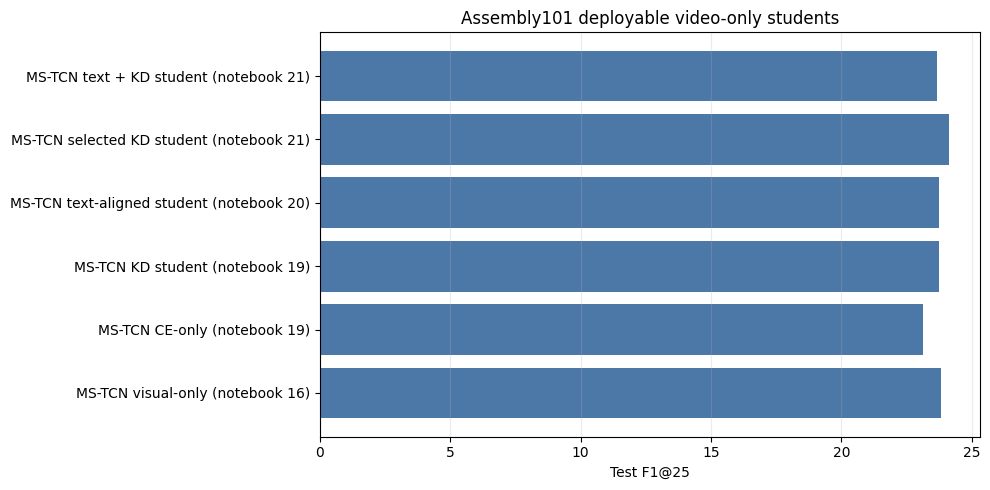

,strategy,validation_score,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50
0,notebook21_selected_kd,26.208221,30.42,26.36,29.60,25.94,19.27
1,notebook20_text_only,26.063486,30.52,26.53,29.25,25.80,19.03
2,notebook21_combined_text_kd,25.691897,30.00,26.28,29.24,25.43,18.31


,group,strategy,hyperparameters,training_text,inference_text,deployable,acc,edit,f1@10,f1@25,f1@50
0,architecture baseline,MS-TCN visual-only (notebook 16),CE,False,False,True,25.86,25.01,28.00,23.82,17.58
1,controlled student,MS-TCN CE-only (notebook 19),lambda_KD=0,False,False,True,25.94,24.75,27.58,23.14,16.53
2,oracle teacher,MS-TCN concat teacher (notebook 18),video + GT text,True,True,False,44.27,37.39,41.65,40.94,36.81
3,original KD,MS-TCN KD student (notebook 19),"lambda=0.1, T=4.0, all stages",True,False,True,26.38,24.64,28.40,23.75,17.73
4,text embedding,MS-TCN text-aligned student (notebook 20),"learnable, beta=0.01",True,False,True,26.27,24.78,28.58,23.76,17.56
5,expanded KD,MS-TCN selected KD student (notebook 21),"lambda=0.2, T=4.0, policy=all",True,False,True,25.67,25.10,28.22,24.11,17.36
6,combined,MS-TCN text + KD student (notebook 21),"beta=0.01, lambda=0.2, T=4.0, policy=all",True,False,True,26.24,24.85,28.73,23.67,17.32


,metric,expanded_kd_minus_old_kd,combined_minus_text,combined_minus_expanded_kd,combined_minus_ce
0,acc,-0.71,-0.03,0.57,0.30
1,edit,0.46,0.07,-0.25,0.10
2,f1@10,-0.18,0.15,0.51,1.15
3,f1@25,0.36,-0.09,-0.44,0.53
4,f1@50,-0.37,-0.24,-0.04,0.79


Recommended deployable strategy by validation: notebook21_selected_kd
Selection used test data: False
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/stage_a_kd_lambda_search.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/stage_b_temperature_search.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/stage_c_stage_policy_search.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/deployment_validation_selection.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features

In [17]:
text_validation_metrics = selected_text["validation_metrics"]
matching_text_rows = [
    row
    for row in notebook20["validation_ablation"]
    if row["strategy"] == SELECTED_TEXT_MODE
    and math.isclose(float(row["text_beta"]), SELECTED_TEXT_BETA)
]
if len(matching_text_rows) != 1:
    raise RuntimeError(
        "Could not uniquely recover notebook 20's selected validation row."
    )
text_validation_score = float(
    matching_text_rows[0]["selection_score"]
)

deployment_candidates = [
    {
        "strategy": "notebook20_text_only",
        "validation_score": text_validation_score,
        "val_acc": text_validation_metrics["acc"],
        "val_edit": text_validation_metrics["edit"],
        "val_f1@10": text_validation_metrics["f1@10"],
        "val_f1@25": text_validation_metrics["f1@25"],
        "val_f1@50": text_validation_metrics["f1@50"],
    },
    {
        "strategy": "notebook21_selected_kd",
        "validation_score": selected_kd_candidate["best_validation_score"],
        **{
            f"val_{key}": value
            for key, value in selected_kd_candidate[
                "best_validation_metrics"
            ].items()
        },
    },
    {
        "strategy": "notebook21_combined_text_kd",
        "validation_score": combined_summary["best_validation_score"],
        **{
            f"val_{key}": value
            for key, value in combined_summary[
                "best_validation_metrics"
            ].items()
        },
    },
]
deployment_df = (
    pd.DataFrame(deployment_candidates)
    .sort_values(
        ["validation_score", "val_f1@25", "val_edit"],
        ascending=False,
    )
    .reset_index(drop=True)
)
recommended_deployable_strategy = str(
    deployment_df.iloc[0]["strategy"]
)
deployment_csv = OUT_ROOT / RUN_MODE / "deployment_validation_selection.csv"
deployment_md = OUT_ROOT / RUN_MODE / "deployment_validation_selection.md"
deployment_df.to_csv(deployment_csv, index=False)
deployment_md.write_text(
    deployment_df.to_markdown(index=False), encoding="utf-8"
)

visual_metrics = notebook19["external_visual_baseline"]["test_metrics"]
ce_metrics = notebook19["controlled_ce"]["test"]["metrics"]
old_kd_metrics = notebook19["selected_kd_student"]["test"]["metrics"]
teacher_metrics = notebook19["teacher"]["oracle_test_metrics"]
text_metrics = selected_text["test"]["metrics"]

final_rows = [
    {
        "group": "architecture baseline",
        "strategy": "MS-TCN visual-only (notebook 16)",
        "hyperparameters": "CE",
        "training_text": False,
        "inference_text": False,
        "deployable": True,
        **{key: float(visual_metrics[key]) for key in [
            "acc", "edit", "f1@10", "f1@25", "f1@50"
        ]},
    },
    {
        "group": "controlled student",
        "strategy": "MS-TCN CE-only (notebook 19)",
        "hyperparameters": "lambda_KD=0",
        "training_text": False,
        "inference_text": False,
        "deployable": True,
        **ce_metrics,
    },
    {
        "group": "oracle teacher",
        "strategy": "MS-TCN concat teacher (notebook 18)",
        "hyperparameters": "video + GT text",
        "training_text": True,
        "inference_text": True,
        "deployable": False,
        **{key: float(teacher_metrics[key]) for key in [
            "acc", "edit", "f1@10", "f1@25", "f1@50"
        ]},
    },
    {
        "group": "original KD",
        "strategy": "MS-TCN KD student (notebook 19)",
        "hyperparameters": (
            f"lambda={notebook19['selected_kd_lambda']}, "
            f"T={notebook19['losses']['temperature']}, all stages"
        ),
        "training_text": True,
        "inference_text": False,
        "deployable": True,
        **old_kd_metrics,
    },
    {
        "group": "text embedding",
        "strategy": "MS-TCN text-aligned student (notebook 20)",
        "hyperparameters": (
            f"{SELECTED_TEXT_MODE}, beta={SELECTED_TEXT_BETA}"
        ),
        "training_text": True,
        "inference_text": False,
        "deployable": True,
        **text_metrics,
    },
    {
        "group": "expanded KD",
        "strategy": "MS-TCN selected KD student (notebook 21)",
        "hyperparameters": (
            f"lambda={selected_kd_candidate['kd_lambda']}, "
            f"T={selected_kd_candidate['temperature']}, "
            f"policy={selected_kd_candidate['stage_policy']}"
        ),
        "training_text": True,
        "inference_text": False,
        "deployable": True,
        **selected_kd_test["metrics"],
    },
    {
        "group": "combined",
        "strategy": "MS-TCN text + KD student (notebook 21)",
        "hyperparameters": (
            f"beta={SELECTED_TEXT_BETA}, "
            f"lambda={combined_summary['kd_lambda']}, "
            f"T={combined_summary['temperature']}, "
            f"policy={combined_summary['stage_policy']}"
        ),
        "training_text": True,
        "inference_text": False,
        "deployable": True,
        **combined_test["metrics"],
    },
]

final_df = pd.DataFrame(final_rows)
final_csv = OUT_ROOT / RUN_MODE / "final_test_comparison.csv"
final_md = OUT_ROOT / RUN_MODE / "final_test_comparison.md"
final_df.to_csv(final_csv, index=False)
final_md.write_text(final_df.to_markdown(index=False), encoding="utf-8")

delta_rows = []
for metric in ["acc", "edit", "f1@10", "f1@25", "f1@50"]:
    delta_rows.append(
        {
            "metric": metric,
            "expanded_kd_minus_old_kd": round(
                float(selected_kd_test["metrics"][metric])
                - float(old_kd_metrics[metric]),
                2,
            ),
            "combined_minus_text": round(
                float(combined_test["metrics"][metric])
                - float(text_metrics[metric]),
                2,
            ),
            "combined_minus_expanded_kd": round(
                float(combined_test["metrics"][metric])
                - float(selected_kd_test["metrics"][metric]),
                2,
            ),
            "combined_minus_ce": round(
                float(combined_test["metrics"][metric])
                - float(ce_metrics[metric]),
                2,
            ),
        }
    )
delta_df = pd.DataFrame(delta_rows)
delta_csv = OUT_ROOT / RUN_MODE / "metric_deltas.csv"
delta_df.to_csv(delta_csv, index=False)

fig, ax = plt.subplots(figsize=(10, 5))
deployable_df = final_df[final_df["deployable"]].copy()
ax.barh(
    deployable_df["strategy"],
    deployable_df["f1@25"],
    color="#4C78A8",
)
ax.set_xlabel("Test F1@25")
ax.set_title("Assembly101 deployable video-only students")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
comparison_plot = OUT_ROOT / RUN_MODE / "deployable_test_f1_25.png"
fig.savefig(comparison_plot, dpi=180, bbox_inches="tight")
plt.show()

display(deployment_df)
display(final_df)
display(delta_df)
print("Recommended deployable strategy by validation:", recommended_deployable_strategy)
print("Selection used test data:", False)

final_summary = {
    "status": "completed",
    "run_mode": RUN_MODE,
    "experiment": "assembly101_staged_kd_search_and_text_kd_student",
    "data": {
        "representation": "clip_vitb16",
        "video_shape": [EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH],
        "num_classes": num_classes,
        "train_sequences": len(train_ids),
        "validation_sequences": len(val_ids),
        "test_sequences": len(test_ids),
    },
    "search_protocol": {
        "selection_score": "validation F1@25 + 0.01 * validation Edit",
        "stage_a": "KD lambda at T=4 and all stages",
        "stage_b": "temperature for selected lambda",
        "stage_c": "all-stage versus final-stage distillation",
        "test_used_for_search": False,
    },
    "stage_a_selected": stage_a_selected,
    "stage_b_selected": stage_b_selected,
    "selected_kd_configuration": selected_kd_candidate,
    "selected_kd_test": selected_kd_test,
    "combined": {
        "validation": combined_summary,
        "test": combined_test,
    },
    "deployment_validation_selection": deployment_df.to_dict(
        orient="records"
    ),
    "recommended_deployable_strategy": recommended_deployable_strategy,
    "final_comparison": final_df.to_dict(orient="records"),
    "metric_deltas": delta_df.to_dict(orient="records"),
    "inference_contract": {
        "call": "student(video)",
        "external_text_input": False,
        "ground_truth_text": False,
        "teacher_called": False,
        "text_auxiliary_head_called": False,
    },
    "paths": {
        "output_root": str(OUT_ROOT),
        "stage_a_search": str(stage_a_csv),
        "stage_b_search": str(stage_b_csv),
        "stage_c_search": str(stage_c_csv),
        "deployment_selection": str(deployment_csv),
        "final_test_comparison": str(final_csv),
        "metric_deltas": str(delta_csv),
        "comparison_plot": str(comparison_plot),
        "selected_kd_predictions": selected_kd_test["prediction_dir"],
        "combined_predictions": combined_test["prediction_dir"],
    },
    "next_step": (
        "Notebook 22: aggregate all Breakfast and Assembly101 results, "
        "create final tables, plots, formulas, conclusions, and "
        "presentation-ready artifacts."
    ),
    "created_utc": datetime.now(timezone.utc).isoformat(),
}

final_summary_path = OUT_ROOT / RUN_MODE / "final_summary.json"
final_summary_path.write_text(
    json.dumps(final_summary, indent=2), encoding="utf-8"
)

print("Saved:", stage_a_csv)
print("Saved:", stage_b_csv)
print("Saved:", stage_c_csv)
print("Saved:", deployment_csv)
print("Saved:", final_csv)
print("Saved:", delta_csv)
print("Saved:", comparison_plot)
print("Saved:", final_summary_path)
print("\nNext notebook:")
print("22_final_ablation_analysis_and_presentation_artifacts_COLAB.ipynb")


## Completion criterion

A complete full run writes:

```text
.../runs/21_text_student_kd_search/full/
├── kd_only/
│   ├── kd_lambda_0p2_temperature_4_policy_all/
│   ├── kd_lambda_0p5_temperature_4_policy_all/
│   ├── kd_lambda_1_temperature_4_policy_all/
│   ├── ... selected-lambda temperature runs ...
│   └── ... selected-pair final-stage run ...
├── combined/
│   └── combined_text_.../
├── test_predictions/
├── stage_a_kd_lambda_search.csv
├── stage_b_temperature_search.csv
├── stage_c_stage_policy_search.csv
├── deployment_validation_selection.csv
├── final_test_comparison.csv
├── metric_deltas.csv
├── deployable_test_f1_25.png
└── final_summary.json
```

The main result is whether the validation-selected combined text + KD
student improves over CE-only, original KD, expanded KD, and text-only
students while preserving strictly video-only inference.
